# 15b — EnMAP tile to CHIME Converter

**Aim:** use EnMAP tile, fit smooth spectra with Bi&Hieronymi at 1 nm, convolve to CHIME, add CHIME noise, create a CHIME-like spatial dataset

1. **Segment** the image into spectrally coherent superpixels (SLIC), **Mean** spectrum of superpixel
3. **Invert** the mean spectrum of each superpixel with *lmfit bi_jax*
5. **Forward simulations** in bio_optics_dev for the mean spectra at 1nm resolution
6. **Convolve** to CHIME bands, and EnMAP bands for error of spectral fit
7. **Back-interpolate Spectra** of convolved spectra to full pixel resolution using PCA + kNN IDW
8. **Back-interpolate Conc** add also all varied parameters from inversion
9. **CHIME Noise** to each spectrum individually
10. **to do: Write to file**

***Example: North Sea EnMAP***

| Step | Key parameter | Paper default |
|---|---|---|
| SLIC `n_segments` | target superpixel count | ~1% of pixels |
| SLIC `compactness` | shape vs spectral fidelity | 0.1 (low → follow edges) |
| SLIC `sigma` | pre-smoothing | 2.0 |
| PCA `n_components` | spectral embedding dims | 6 |
| kNN `k` | neighbours for IDW | 4 |

Reference: Adams et al. (2021), *Remote Sensing of Environment*.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import time
import numpy as np
import xarray as xr
import lmfit
import matplotlib.pyplot as plt
import pandas as pd
import jax.numpy as jnp
import cmocean.cm as cm
from skimage.segmentation import mark_boundaries
from xcube.core.store import new_data_store
from suncalc import get_position, get_times
from sunpy.coordinates.sun import earth_distance

from bio_optics.water.reflectance import bi_jax, bi_fluo, lee
from bio_optics.inversion import lmfit_engine
from bio_optics.image_processing import superpixel_engine


In [2]:
%reload_ext autoreload

In [3]:
def find_closest(arr: np.array, val: int):
  """ 
  Find the closest value to a number in an array.
  
  :param arr:  an array or list of numbers
  :param val:  the number  
  :return:     the closest value and its index in arr
  """
  arr = np.asarray(arr)
  idx = (np.abs(arr - val)).argmin()
  
  return arr[idx], idx

# Load data

## Same Sentinel-2 Wadden Sea scene as NB07b.

In [2]:
dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))

wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])
band_vars   = list(dataset.data_vars)[1:]

ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(ref_band.dims)
spatial_coords    = {d: dataset[d].values for d in spatial_dim_names if d in dataset.coords}

Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

Rrs_image: (267, 449, 8)  (119883 pixels, 8 bands)


## EnMAP Wadden Sea

In [4]:
root = 'D:\Documents\projects\EnsAD\EnMAP\L2A_Water\\v010502\Waddensea\zarr\\'
zarrList = os.listdir(root)
dateList = ['20240530', '20240626', '20240727', '20240819', '20240831', '20241112']
## goodExamples = {'20240626': ['_005_', '_006_', '_007_'], '20240727': ['_001_', '_002_', '_003_'], 
##    '20240819':['_004_', '_005_', '_007_' ], '20240831':['_001_', '_002_'], '20241112'}
dateStr= dateList[4]
zarrList = [z for z in zarrList if dateStr in z]
print(len(zarrList))
zarrFname = zarrList[1]
print(zarrFname)
local = new_data_store("file", root=root)
dr = local.open_data(zarrFname)
wl = dr.band.values
ind665_, ind665 = find_closest(wl, 665)
ind560_, ind560 = find_closest(wl, 560)
ind440_, ind440 = find_closest(wl, 440)

flags2D = dr.quality_classes.values[:,:]

# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865]) # selection
ID = wl < 850.
wavelengths = wl[ID]
band_vars = []
for w in wavelengths:
    ind_, ind = find_closest(wl, w)
    band_vars.append(ind)

# print(band_vars)

# ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(dr.band_data.isel(band=0).dims)
spatial_coords    = {d: dr[d].values for d in spatial_dim_names if d in dr.coords}

Rrs_image = np.stack(
    [dr.band_data.isel(band=v).values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
n_pixels_valid = np.sum(np.sum(np.logical_not(np.isnan(Rrs_image)), axis=-1)>0)
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_pixels_valid} valid water pixels, {n_obs} bands)')

## Time, Geometry,
datetime = dateStr + zarrFname.split(dateStr)[1].split('_')[0]
df_time = pd.DataFrame()
df_time.datetime = pd.to_datetime(datetime)
print(datetime)
lon_mean = np.mean(spatial_coords['x'])
lat_mean = np.mean(spatial_coords['y'])

sun_dict = get_position(df_time.datetime, lng=lon_mean, lat=lat_mean)
sun_dict['zenith'] = (np.pi / 2. - sun_dict['altitude']) * 180. / np.pi
sun_dict['azimuth'] = (sun_dict['azimuth']) * 180. / np.pi

## Prepare Angle dependency
## date, location for scene are used above to calculate the sun_dict!
G_df, solz, senz, phi = lee.read_G_LUT()
xG0w = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G0w')
xG1w = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G1w')
xG0p = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G0p')
xG1p = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G1p')

## Sensor Zenith Angle, Azimuth Difference
senz, phi = (5., 135.) # (50., 135.)  # (30., 135.) # (0,0) # for consistency with Pitarch et al 2025, the azimuth difference has to be transformed!
G0w = xG0w.interp(solz=sun_dict['zenith'], senz=senz, phi=180.-phi, method="linear").values.flatten()[0]
G1w = xG1w.interp(solz=sun_dict['zenith'], senz=senz, phi=180.-phi, method="linear").values.flatten()[0]
G0p = xG0p.interp(solz=sun_dict['zenith'], senz=senz, phi=180.-phi, method="linear").values.flatten()[0]
G1p = xG1p.interp(solz=sun_dict['zenith'], senz=senz, phi=180.-phi, method="linear").values.flatten()[0]

2
enmapZarr_ENMAP01-____L2A-DT0000090299_20240831T112133Z_002_V010502_20250116T085503Z.zarr
Rrs_image: (930, 1648, 73)  (1532640 pixels, 286874 valid water pixels, 73 bands)
20240831T112133Z


In [5]:
sun_dict

{'azimuth': np.float64(-2.3446852549443675),
 'altitude': np.float64(0.785118434919789),
 'zenith': np.float64(45.016027261179495)}

## EnMAP North Sea

In [4]:
root = 'D:\Documents\projects\EnsAD\EnMAP\L2A_Water\\v010502\\NorthSea\zarr\\'
zarrList = os.listdir(root)
dateList = ['20230806', '20230809', '20230815']
## goodExamples = {'20230806':[], '20230809':['_001_','_002_','_003_'], '20230815':['_001', '_002_', '_003_']}
zarrList = [z for z in zarrList if dateList[2] in z]
print(len(zarrList))
zarrFname = zarrList[1]
print(zarrFname)
local = new_data_store("file", root=root)
dr = local.open_data(zarrFname)
wl = dr.band.values
ind665_, ind665 = find_closest(wl, 665)
ind560_, ind560 = find_closest(wl, 560)
ind440_, ind440 = find_closest(wl, 440)

print(ind440, ind560, ind665)

flags2D = dr.quality_classes.values[:,:]


# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865]) # selection
ID = wl < 850.
wavelengths = wl[ID]
band_vars = []
for w in wavelengths:
    ind_, ind = find_closest(wl, w)
    band_vars.append(ind)

# print(band_vars)

# ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(dr.band_data.isel(band=0).dims)
spatial_coords    = {d: dr[d].values for d in spatial_dim_names if d in dr.coords}

Rrs_image = np.stack(
    [dr.band_data.isel(band=v).values for v in band_vars], axis=-1
) #/ np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

3
enmapZarr_ENMAP01-____L2A-DT0000035300_20230815T111709Z_002_V010506_20260326T164446Z.zarr
4 29 47
Rrs_image: (917, 1572, 73)  (1441524 pixels, 73 bands)


## Further steps  
- destriping ?! Seems necessary, otherwise no clusters are formed, if the scene is pure water!

47 29 4
NDWI [561.112 871.683]


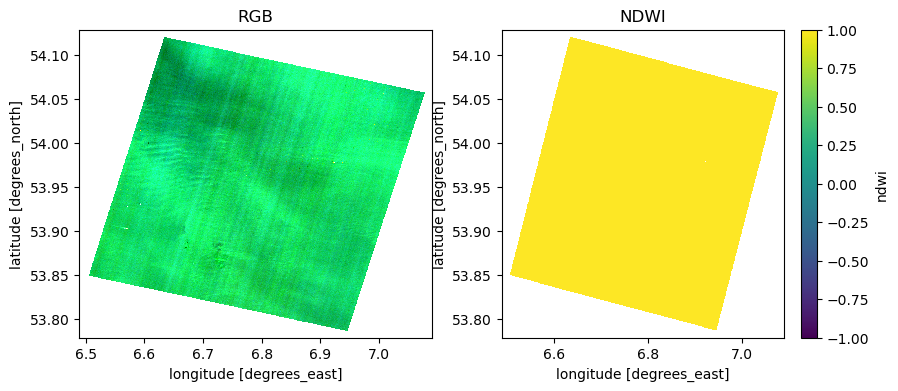

In [5]:
# dr.band_data.isel(band=10).plot()
print(ind665, ind560, ind440)
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
dr.band_data.isel(band = [ind665, ind560, ind440]).plot.imshow(ax=ax[0], robust=True)
ax[0].set_title('RGB')

Rrs_ndwi = dr.band_data.isel(band=[29,75]).values #dr.band_data.isel(band=[29, 75]).values
print('NDWI', wl[[29, 75]])
ndwi = (Rrs_ndwi[0,:,:] - Rrs_ndwi[1,:,:]) / (Rrs_ndwi[0, :,:] + Rrs_ndwi[1, :,:])
dr = dr.assign(ndwi=(['y', 'x'], ndwi))
dr.ndwi.plot(ax=ax[1], vmin=-1, vmax=1)
ax[1].set_title('NDWI')
plt.show()

# Processing

## Configuration Bi & Hieronymi

In [6]:
regionName='NorthSea'
sensor = 'EnMAP'
versionAC = 'EnMAPWaterv1.5.2'
dataType = 'EnMAPTile' # 'Sim'
## CAUTION: only Standardv2 is implemented here!! ##
AlgaeGroupType = 'Standardv2' #'Standardv2' # 'Standardv3' # 'NSSummerBloomsv3' Standardv2, 'HEREONgold'

# maxWavelength= 750.
maxWavelength = 850.

In [7]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.002, vary=False)  # Diatoms 0.0058; HEREONweb: 0.002
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green 0.007, HEREONweb: 0.007
    params.add('b_ratio_C_2', value=0.002, vary=False)  # cryptophyte 0.0042, HEREONweb: 0.002
    params.add('b_ratio_C_3', value=0.003, vary=False)  # cyano blue 0.0082, HEREONweb: 0.003
    params.add('b_ratio_C_4', value=0.003, vary=False)  # cyano red 0.001, HEREONweb: 0.003
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    elif AlgaeGroupType == 'HEREONgold':
        params.add('b_ratio_C_5', value=0.002, vary=False)
    else:
        params.add('b_ratio_C_5', value=0.0129,
                   vary=False)  # coccolithophores 0.0129, , HEREONweb: 0.007, Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates 0.0209, HEREONweb: not available
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.007,
                   vary=False)  # case-1 0.0109, HEREONweb: 0.007, Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=False)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.020, min=0.018, max=0.022, vary=False) # Helsinki: 0.018 -0.022; test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A_phy', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=False, vary=False) # value=True
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params


def setDictValues(value, vmin, vmax):
    dd = {'value': value, 'min': vmin, 'max': vmax}
    return dd

In [8]:
## North Sea
processingDict = {
    'C_0': setDictValues(0,0,200), #brown
    # 'C_1': setDictValues(0.1,0,200), #green
    'C_2': setDictValues(0,0,200), # crypto
    'C_3': setDictValues(0,0,200), # cyano blue
    # 'C_4': setDictValues(0,0,100), # cyano red
    #'C_5': setDictValues(0,0,200), # coccolith.
    'C_6': setDictValues(0,0,200), # dinoflagellate
    'C_Y': setDictValues(0,0,1),
    'C_ism': setDictValues(0,0,150),
    'S_cdom': setDictValues(0.020, 0.018, 0.022)
    # 'L_fl_lambda0': setDictValues(0,0,0.2),
    # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
    # 'L_fl_phycocyanin': setDictValues(0,0,0.2),
    # 'offset': setDictValues(0, -0.1, 0.1)
}

In [9]:
noise     = 1
n_iter    = 200 #15
tile_size = 4096


# --- build lmfit Parameters --------------------------------------------------
paramDict = processingDict
params = set_default_parameters(AlgaeGroupType)
params = set_parameters_byDict(paramDict, params)


# sigma_a    = {n: c['sigma_a'] for n, c in fit_config.items() if c['vary']}
# log_params = [n for n, c in fit_config.items() if c['vary'] and c['log']]


In [10]:
# --- precompute --------------------------
pre_base     = bi_jax.precompute(wavelengths)
pre = {**pre_base}

def forward_func(params, wavelengths):
    """Adapter: lmfit_engine signature → bi_jax.forward."""
    return np.array(bi_jax.forward(params, pre))
    # return np.array(bi_fluo.forward(params, pre)) # TODO: does not work yet!

setup = lmfit_engine.build_inversion(
    params,
    wavelengths,
    forward_func,
    method='least-squares',
    max_nfev=n_iter,
)
print(f'fit_names : {setup.fit_names}')

fit_names : ['C_0', 'C_2', 'C_3', 'C_6', 'C_Y', 'C_ism', 'S_cdom']


## Step 1 — SLIC segmentation

`compactness=0.1` allows superpixel shapes to follow natural spectral edges  
(water eddies, depth gradients) rather than enforcing compact blobs.  
`sigma=2.0` reduces the impact of per-pixel spectral noise on cluster assignment.

In [11]:
# SLIC parameters (paper defaults)
IDvalid = np.logical_not(np.isnan(Rrs_image[:,:,0]))

n_segments  = np.sum(IDvalid) / 100. #1200   # ~1% of 119 883 pixels
compactness = 0.1 
slic_sigma  = 2.0

t0     = time.perf_counter()
labels = superpixel_engine.segment_image(
    Rrs_image, n_segments=n_segments,
    compactness=compactness, sigma=slic_sigma,
)
t_seg  = time.perf_counter() - t0

n_segs_actual = len(np.unique(labels))
print(f'Requested {n_segments} segments → got {n_segs_actual}  ({t_seg:.2f} s)')
print(f'Mean pixels per segment: {n_pixels / n_segs_actual:.0f}')

Requested 2868.74 segments → got 2743  (25.08 s)
Mean pixels per segment: 559


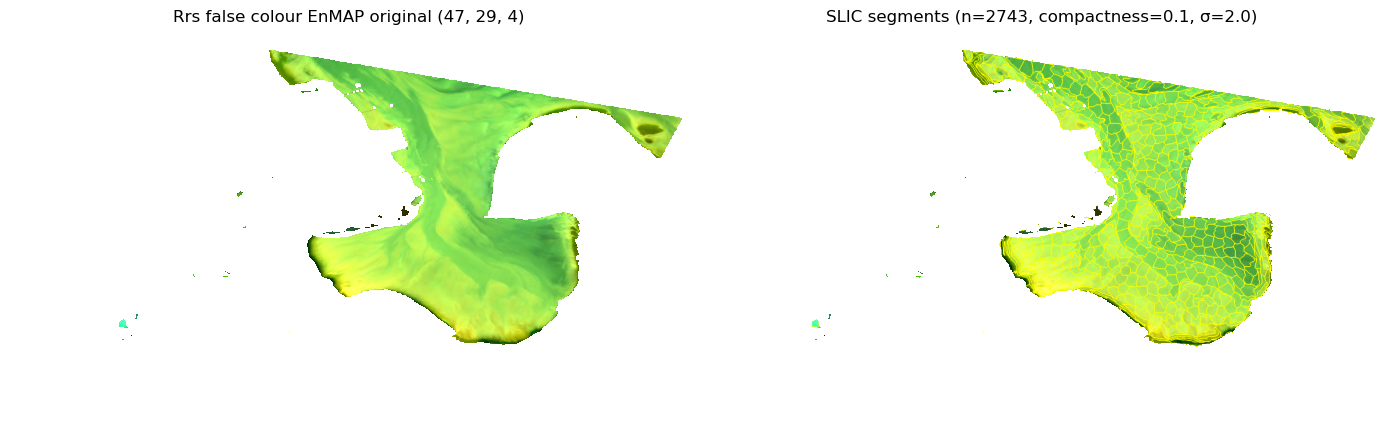

In [12]:
# False-colour RGB for overlay
rgb_bands = [ind665, ind560, ind440]   # B04, B03, B02 → R, G, B
rgb = Rrs_image[..., rgb_bands]
rgb = (rgb - np.nanpercentile(rgb, 2)) / (np.nanpercentile(rgb, 98) - np.nanpercentile(rgb, 2))
rgb = np.clip(rgb, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(rgb, origin='upper')
BandStr = str(ind665) + ', ' + str(ind560) + ', ' + str(ind440)
axes[0].set_title('Rrs false colour EnMAP original ('+BandStr +')')
axes[0].axis('off')

# mark_boundaries draws segment outlines on the image
img_boundaries = mark_boundaries(rgb, labels, color=(1, 1, 0), mode='thick')
axes[1].imshow(img_boundaries, origin='upper')
axes[1].set_title(f'SLIC segments (n={n_segs_actual}, compactness={compactness}, σ={slic_sigma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Step 1.1 — Aggregate superpixel mean spectra

sp_spectra shape: (2743, 73)
valid sp_spectra: 660
Pixel counts (in valid superpixel) — min: 1  median: 483  max: 1653


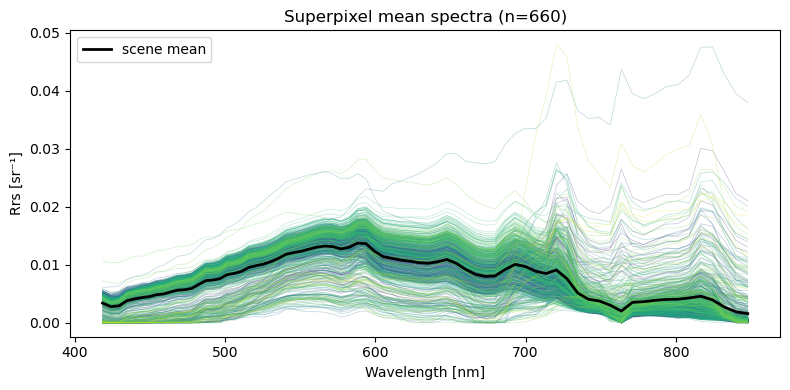

In [13]:
sp_spectra, sp_counts = superpixel_engine.aggregate_superpixels(Rrs_image, labels)

valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
print(f'sp_spectra shape: {sp_spectra.shape}')
print(f'valid sp_spectra: {len(valid)}')
print(f'Pixel counts (in valid superpixel) — min: {sp_counts[valid].min()}  median: {np.nanmedian(sp_counts[valid]):.0f}  max: {sp_counts[valid].max()}')

fig, ax = plt.subplots(figsize=(8, 4))
cvals = np.linspace(0, 1, n_segs_actual)
n_segs_actual_noNaN = 0
for i in range(n_segs_actual):
    if np.sum(np.logical_not(np.isnan(sp_spectra[i])))>0:
        n_segs_actual_noNaN +=1
        ax.plot(wavelengths, sp_spectra[i], color=plt.cm.viridis(cvals[i]), alpha=0.3, lw=0.5)
ax.plot(wavelengths, np.nanmean(sp_spectra, axis=0), 'k-', lw=2, label='scene mean')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.set_title(f'Superpixel mean spectra (n={n_segs_actual_noNaN})')
ax.legend()
plt.tight_layout()
plt.show()

### Step 1.2 — Write mean spectra to file

In [109]:
## write mean spectra to file
import pandas as pd
valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
outdf = pd.DataFrame(sp_spectra[valid,:], columns=[str(a) for a in wavelengths])
outpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\\"
#zarrFname: enmapZarr_ENMAP01-____L2A-DT0000090299_20240831T112133Z_002_V010502_20250116T085503Z.zarr
outfile = zarrFname.split('enmapZarr_ENMAP01-____L2A-')[1].split('.zarr')[0]
outdf.to_csv(outpath + "EnMAPsuperpixel_"+outfile +'_c.txt',  sep='\t', header=True, index=False)

## Step 2 — Least Square inversion of superpixel mean spectra

Each superpixel is inverted independently using the same `setup`.  
**ToDO**
- lmfit is still slow! 660 spectra take 6min.
-

### Angle dependency
One set of angles for the EnMAP scene!

In [14]:
params.add("Gw0", value=G0w, vary=False)
params.add("Gw1", value=G1w, vary=False)
params.add("Gp0", value=G0p, vary=False)
params.add("Gp1", value=G1p, vary=False)

setup = lmfit_engine.build_inversion(
    params,
    wavelengths,
    forward_func,
    method='least-squares',
    max_nfev=n_iter,
)

### Inversion

In [15]:
## Restricted to valid pixels ## 
t0 = time.perf_counter()
sp_results = superpixel_engine.invert_superpixels(
    sp_spectra[valid,:], sp_counts[valid], setup, noise,
    invert_fn = lmfit_engine.invert_image,
    # max_steps=100, tile_size=tile_size
)
t_sp = time.perf_counter() - t0

print(f'Superpixel inversion: {n_segs_actual_noNaN} segments in {t_sp:.2f} s')
print(f'Speedup vs full image (~{n_pixels_valid} px): {n_pixels_valid / n_segs_actual_noNaN:.0f}× fewer inversions')

Superpixel inversion: 660 segments in 512.42 s
Speedup vs full image (~286874 px): 435× fewer inversions


In [19]:
sp_results.keys()

dict_keys(['x_hat', 'chi2', 'success', 'n_nfev', 'fit_names'])

### Analysis inversion

In [35]:
Rrs_sim_jax_Arr = np.zeros((len(valid), len(wavelengths)))

for i in range(sp_results['x_hat'].shape[0]):  #paramDF.shape[0]:
    for j, p in enumerate(sp_results['fit_names']):
        # Change parameters object accordingly.
        # if p.startswith('C_'):
        #     print(p, np.round(paramDF[p].values[i] / invIOP['C_phy'].values[i], 2))
        params.add(p, value=sp_results['x_hat'][i][j])

    R_rs_sim_jax = bi_jax.forward(params, pre)
    Rrs_sim_jax_Arr[i,:] = R_rs_sim_jax

250


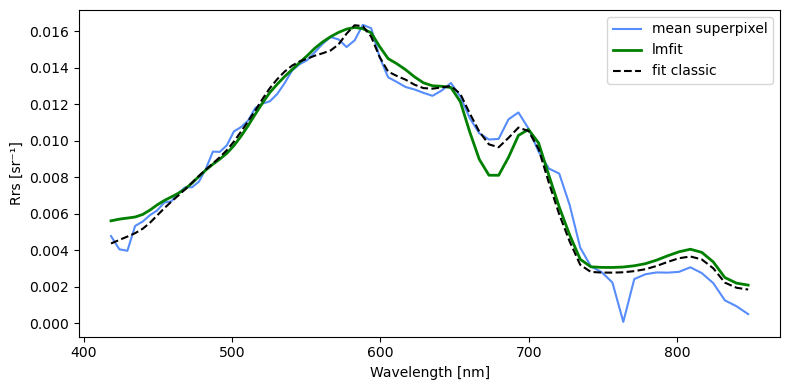

In [39]:
i = 250
print(i)
vi = i

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelengths, sp_spectra[valid,:][i,:], '-', label='mean superpixel')
ax.plot(wavelengths, Rrs_sim_jax_Arr[i,:], 'g-', lw=2, label='lmfit')

# ax.plot(wavelengths, sp_results['y_hat'][i], 'k-', lw=2, label='fit')
# ax.plot(invWL, invRrs.iloc[vi,:], 'k--',  label='fit classic')
# ax.set_title('chi2 ' +str(np.round(sp_results['chi2'][i], 4)))
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.legend()
plt.tight_layout()
plt.show()

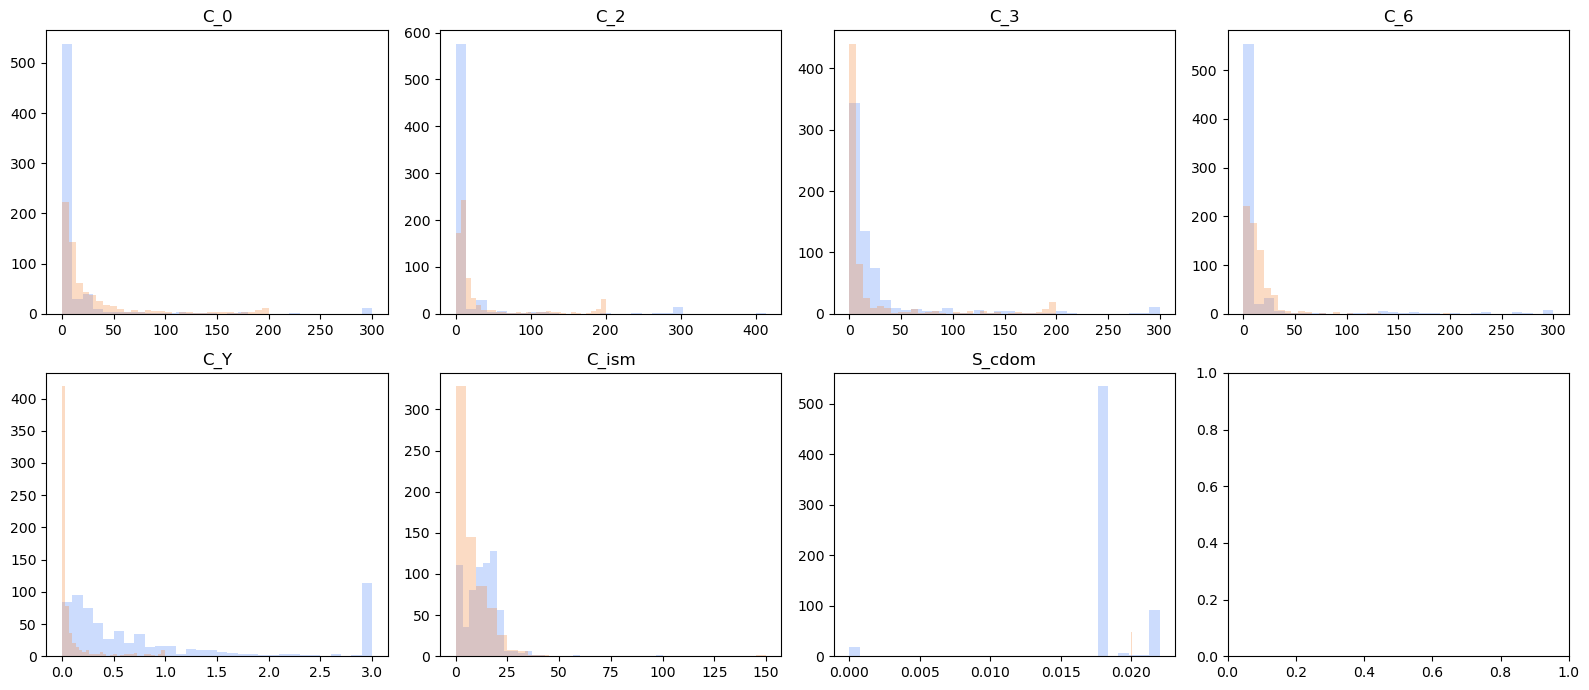

In [53]:
Nx, Ny = (4, 2)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(16, 7.))
ix, iy = (0,0)
binDict = {
    'C_0': 10.**np.arange(-1.,np.log10(300), 0.1),
    'C_2': 10.**np.arange(-1.,np.log10(300), 0.1),
    'C_3': 10.**np.arange(-1.,np.log10(300), 0.1),
    'C_6': 10.**np.arange(-1.,np.log10(300), 0.1),
    'C_Y': np.arange(0.,3, 0.1),
    'C_ism': 10.**np.arange(-1.,np.log10(30), 0.1),
    'S_cdom': np.arange(0.017,0.028, 0.0001)
}
for i, p in enumerate(sp_results['fit_names']):
    # ax[iy, ix].plot(invIOP[p].values, sp_results['x_hat'][:, i], '+')

    ax[iy, ix].hist(invIOP[p].values, 30, alpha=0.3, label='external')
    ax[iy, ix].hist(sp_results['x_hat'][:, i], 30, alpha=0.3, label='bi_jax')

    ax[iy, ix].set_title(p)
    # ax[iy, ix].set_xlabel('external inversion')
    # ax[iy, ix].set_ylabel('lmfit bi_jax')
    ix +=1
    if ix == Nx:
        ix =0
        iy+=1
fig.tight_layout()
plt.show()

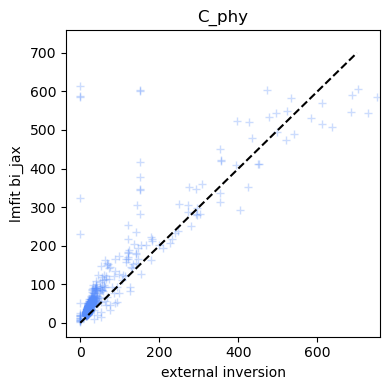

In [48]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(invIOP['C_phy'].values, np.sum(sp_results['x_hat'][:, :4], axis=1), '+', alpha=0.3)
ax.plot((0,700), (0,700), 'k--')
lim = ax.get_ylim()
ax.set_xlim(lim)
ax.set_title('C_phy')
ax.set_xlabel('external inversion')
ax.set_ylabel('lmfit bi_jax')
fig.tight_layout()
plt.show()

## Step x -- Read Inversion results

In [37]:
## read full inversion old way
import pandas as pd
inpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\FullInversion\\"
fnames = os.listdir(inpath)
## b: with fluorescence, c: no fluorescence
rrsFname = [fn for fn in fnames if fn.startswith('inverted_Sim') and fn.endswith('c.txt') and 'c_withOWT' in fn][0]
print(rrsFname)
invRrs = pd.read_csv(inpath+ rrsFname, header=0)
invWL = np.asarray([float(a) for a in invRrs.columns.values])
iopFname = [fn for fn in fnames if fn.startswith('inverted_IOP') and fn.endswith('c.txt') and 'c_withOWT' in fn][0]

invIOP =  pd.read_csv(inpath+ iopFname, header=0)
print(invIOP.shape)
print(invRrs.shape)

inverted_Sim_bio_optics_HEREONfull__c_withOWT_allOWTs_Inv0.1c.txt
(660, 84)
(660, 73)


10


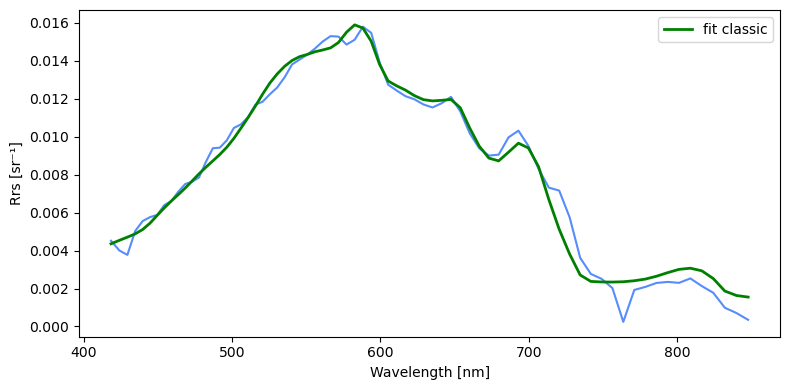

In [113]:
## only valid spectra inverted:
# minchi = sp_results['chi2'] == np.min(sp_results['chi2'])
# i = np.where(minchi)[0][0]
i = 10
print(i)
vi = i

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelengths, sp_spectra[valid,:][i,:])
# ax.plot(wavelengths, sp_results['y_hat'][i], 'k-', lw=2, label='fit')
ax.plot(invWL, invRrs.iloc[vi,:], 'g-', lw=2, label='fit classic')
# ax.set_title('chi2 ' +str(np.round(sp_results['chi2'][i], 4)))
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
## spectral errors
def setup_spectral_error_df(Xtrain, X_projected):
    SpectralErrorDF = pd.DataFrame()

    rMAE = np.zeros(Xtrain.shape[0])
    sam = np.zeros(Xtrain.shape[0])

    rMAE = np.sqrt(np.sum((Xtrain - X_projected) ** 2, axis=1)) / np.sum(Xtrain, axis=1)
    sqrtsum2_orig = np.sqrt(np.sum(Xtrain ** 2, axis=1))
    sqrtsum2_inv = np.sqrt(np.sum(X_projected ** 2, axis=1))
    sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)
    sam = np.arccos(sam)

    sam *= 180. / np.pi
    SpectralErrorDF['rMAE'] = rMAE
    SpectralErrorDF['SAM'] = sam
    SpectralErrorDF['absErr'] = np.sum(np.abs(X_projected - Xtrain), axis=1)
    SpectralErrorDF['noise'] = np.sum(np.abs(np.diff(Xtrain)), axis=1)

    return SpectralErrorDF

In [17]:
errorDF = setup_spectral_error_df(sp_spectra[valid,:],invRrs.values)

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_3372\488529948.py:11: RuntimeWarning: invalid value encountered in divide
  sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)


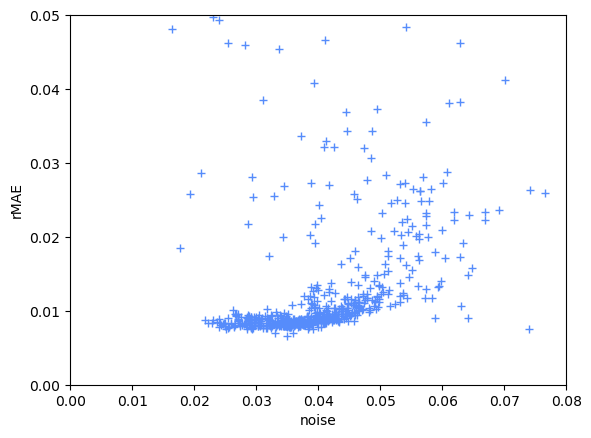

In [20]:
plt.plot(errorDF.noise, errorDF.rMAE, '+')
plt.xlabel('noise')
plt.ylabel('rMAE')
plt.xlim((0,0.08))
plt.ylim((0,0.05))
plt.show()

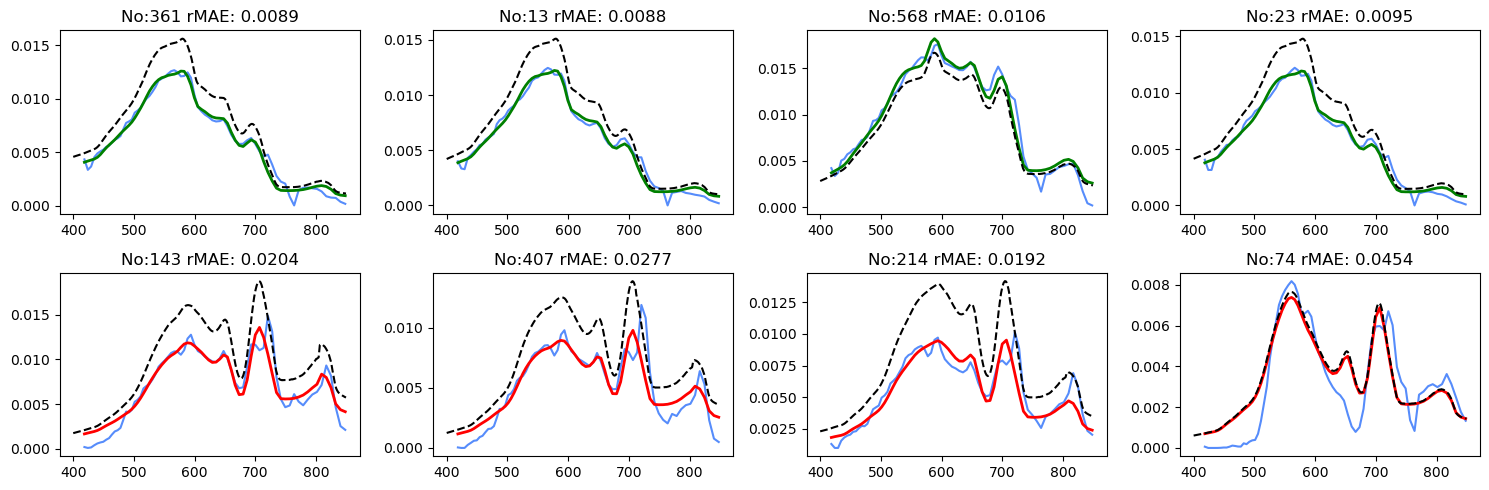

In [37]:
IDgood = errorDF.rMAE.values < 0.015
IDbad = errorDF.rMAE.values > 0.015
N = 4
ind_good = np.random.choice(np.where(IDgood)[0], size=N, replace=False)
ind_bad = np.random.choice(np.where(IDbad)[0], size=N, replace=False)

fig, ax = plt.subplots(nrows=2, ncols=N, figsize=(15, 5))
for ix in range(N):
    ax[0, ix].plot(wavelengths, sp_spectra[valid,:][ind_good[ix],:], '-')
    ax[0, ix].plot(invWL, invRrs.iloc[ind_good[ix],:], 'g-', lw=2, label='fit classic')
    ax[0, ix].plot(wl1nm, Rrs_sim_jax_Arr[ind_good[ix],:], 'k--')
    ax[0, ix].set_title('No:' + str(ind_good[ix]) + ' rMAE: '+ str(np.round(errorDF.rMAE.values[ind_good[ix]],4)))
    ax[1, ix].plot(wavelengths, sp_spectra[valid,:][ind_bad[ix],:], '-')
    ax[1, ix].plot(invWL, invRrs.iloc[ind_bad[ix],:], 'r-', lw=2, label='fit classic')
    ax[1, ix].plot(wl1nm, Rrs_sim_jax_Arr[ind_bad[ix],:], 'k--')
    ax[1, ix].set_title('No:' + str(ind_bad[ix]) + ' rMAE: '+ str(np.round(errorDF.rMAE.values[ind_bad[ix]],4)))
fig.tight_layout()
plt.show()

In [30]:
print(np.sum(IDgood), np.sum(IDbad))

430 230


### check Inversion results and spectra

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_4500\1395112846.py:24: RuntimeWarning: invalid value encountered in log10
  ax[iy, ix].hist(np.log10(sp_results['x_hat'][:,i]), 30)


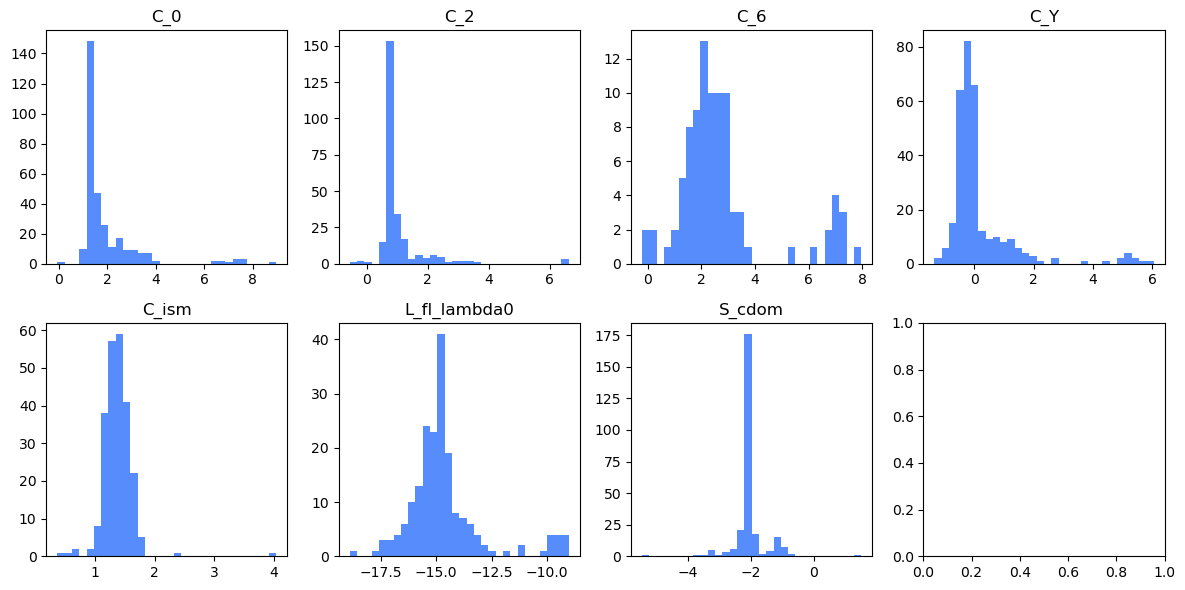

In [79]:
# # Overview inversion
# Nx, Ny = (4,2)
# fig, ax = plt.subplots(Ny, Nx, figsize=(12,6))
# ix, iy = (0,0)
# for i, key in enumerate(fit_config.keys()):
#     if fit_config[key]['log']:
#         ax[iy, ix].hist(np.log10(sp_results['x_hat'][valid,i]), 30)
#     else:
#         ax[iy, ix].hist(sp_results['x_hat'][valid,i], 30)
#     ax[iy, ix].set_title(key)
#     ix +=1
#     if ix == Nx:
#         ix=0
#         iy+=1
# fig.tight_layout()
# plt.show()

# Overview inversion; valid only
Nx, Ny = (4,2)
fig, ax = plt.subplots(Ny, Nx, figsize=(12,6))
ix, iy = (0,0)
for i, key in enumerate(fit_config.keys()):
    #if fit_config[key]['log']:
    ax[iy, ix].hist(np.log10(sp_results['x_hat'][:,i]), 30)
    # else:
    # ax[iy, ix].hist(sp_results['x_hat'][:,i], 30)
    ax[iy, ix].set_title(key)
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

Median chi2 raw:        1.0164
Median chi2 calibrated: 720.1524  (should be ≈ 1 if noise is well-calibrated)


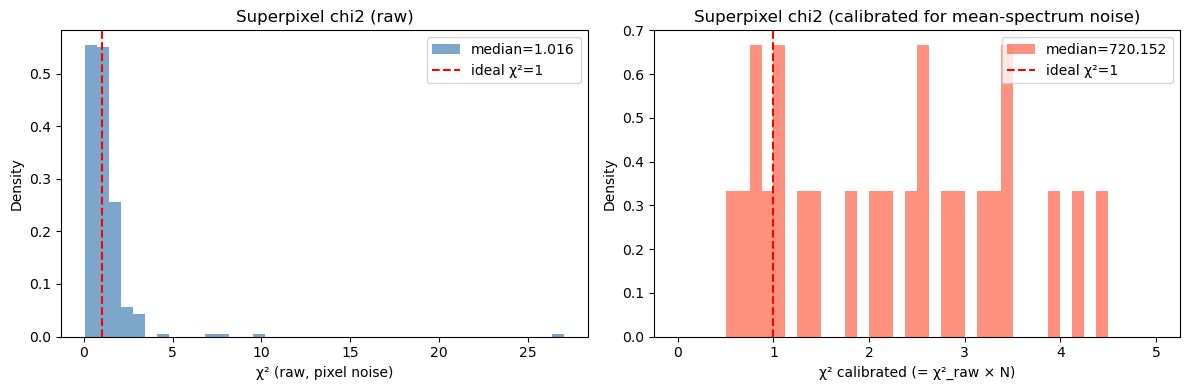

In [54]:
chi2_raw = sp_results['chi2']
chi2_cal = chi2_raw * sp_counts[valid]   # calibrated: chi2 × N

print(f'Median chi2 raw:        {np.nanmedian(chi2_raw):.4f}')
print(f'Median chi2 calibrated: {np.nanmedian(chi2_cal):.4f}  (should be ≈ 1 if noise is well-calibrated)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kw = dict(bins=40, density=True, alpha=0.7)
axes[0].hist(chi2_raw, **kw, color='steelblue', label=f'median={np.nanmedian(chi2_raw):.3f}')
axes[0].axvline(1.0, color='r', ls='--', lw=1.5, label='ideal χ²=1')
axes[0].set_xlabel('χ² (raw, pixel noise)')
axes[0].set_ylabel('Density')
axes[0].set_title('Superpixel chi2 (raw)')
axes[0].legend()

axes[1].hist(chi2_cal, range=(0, 5), **kw, color='tomato', label=f'median={np.nanmedian(chi2_cal):.3f}')
axes[1].axvline(1.0, color='r', ls='--', lw=1.5, label='ideal χ²=1')
axes[1].set_xlabel('χ² calibrated (= χ²_raw × N)')
axes[1].set_ylabel('Density')
axes[1].set_title('Superpixel chi2 (calibrated for mean-spectrum noise)')
axes[1].legend()

plt.tight_layout()
plt.show()



## Step 3 - Forward Simulations
Calculate spectra at 1nm resolution!

In [16]:
wl1nm = np.arange(400., 850., 1.)
pre_base = bi_jax.precompute(wl1nm)
pre = {**pre_base}

In [17]:
Rrs_sim_jax_Arr = np.zeros((len(valid), len(wl1nm)))

for i in range(sp_results['x_hat'].shape[0]):  #paramDF.shape[0]:
    for j, p in enumerate(sp_results['fit_names']):
        # Change parameters object accordingly.
        # if p.startswith('C_'):
        #     print(p, np.round(paramDF[p].values[i] / invIOP['C_phy'].values[i], 2))
        params.add(p, value=sp_results['x_hat'][i][j])

    R_rs_sim_jax = bi_jax.forward(params, pre)
    Rrs_sim_jax_Arr[i,:] = R_rs_sim_jax

## Step 4 - Convolve simulations

#### Convolution to CHIME

In [18]:
SNR = pd.read_csv("Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\CHIME_SNR\SNR_g_No_coeff.csv", header=0)
SNR

,Wavelength [nm],g,N0
0,404.2,298.624928,1.477043
1,412.6,340.045687,1.139124
2,421.0,359.345786,1.020047
3,429.4,362.448827,1.007215
4,437.8,397.359474,0.868355
...,...,...,...
245,2462.2,69.403332,8.525178
246,2470.6,48.706035,17.310059
247,2479.0,32.256519,39.466544
248,2487.4,13.538347,224.043744


In [19]:
def ISRF(wl, wl0):
    FWHM = 10.7
    sigma = FWHM/(2*np.sqrt(2*np.log(2)))
    return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

CHIME_vnir = SNR.iloc[:,0].values[SNR.iloc[:,0].values < maxWavelength]

Rrs_CHIME = np.zeros((len(valid), len(CHIME_vnir)))
weights_Arr = np.zeros((len(wl1nm), len(CHIME_vnir)))
for i, wl0 in enumerate(CHIME_vnir):
    weights = ISRF(wl1nm, wl0)
    weightsnorm = weights / np.sum(weights)
    weights_Arr[:,i] = weightsnorm

Rrs_CHIME = np.matmul(Rrs_sim_jax_Arr, weights_Arr)


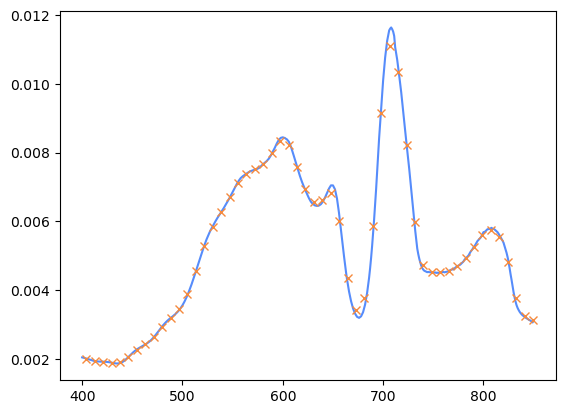

In [58]:
plt.plot(wl1nm, Rrs_sim_jax_Arr[0,:], '-')
plt.plot(CHIME_vnir, Rrs_CHIME[0,:], 'x' )
plt.show()

#### Convolution to EnMAP
for spatial Error characterisation

In [20]:
EnMAP_SRF = pd.read_csv("E:\Documents\projects\EnsAD\c2rcc_test\EnMAP_SRF\EnMAP_Spectral_Bands.txt", header=0, sep='\t')
EnMAP_SRF

,BAND #,CW (nm),FWHM (nm)
0,1,420.93,7.00
1,2,426.46,6.69
2,3,431.80,6.45
3,4,436.96,6.28
4,5,441.98,6.16
...,...,...,...
86,87,964.34,10.71
87,88,972.49,10.70
88,89,980.63,10.67
89,90,988.77,10.62


In [21]:
def ISRF_EnMAP(wl, wl0):
    ind_, ind = find_closest(EnMAP_SRF['CW (nm)'], wl0)
    FWHM = EnMAP_SRF['FWHM (nm)'].values[ind]
    sigma = FWHM/(2*np.sqrt(2*np.log(2)))
    return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

EnMAP_vnir = wavelengths

Rrs_EnMAP = np.zeros((len(valid), len(EnMAP_vnir)))
weights_Arr = np.zeros((len(wl1nm), len(EnMAP_vnir)))
for i, wl0 in enumerate(EnMAP_vnir):
    weights = ISRF_EnMAP(wl1nm, wl0)
    weightsnorm = weights / np.sum(weights)
    weights_Arr[:,i] = weightsnorm

Rrs_EnMAP = np.matmul(Rrs_sim_jax_Arr, weights_Arr)

## Step 5 — Back-interpolation **Spectra**: PCA + kNN IDW

For each pixel, find the k=4 nearest superpixels in 6-component PCA space  
(fitted on brightness-normalised mean spectra), then compute an inverse-distance  
weighted average of their retrieval results.

Uncertainty propagation:
- **Formal**: `σ²_pixel = Σ wᵢ² σ²_spᵢ` — posterior uncertainty propagated through IDW weights
- **Interpolation spread**: `+ Σ wᵢ (x_hat_spᵢ − x_hat_pixel)²` — spread among k neighbours

In [22]:
## Interpolation CHIME convolved spectra ##
k            = 4
n_components = 10

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    Rrs_CHIME,
    # sp_results['x_hat'],
    # sp_sigma=sp_results['sigma'],
    # sp_A_diag=sp_results['A_diag'],
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0


CHIME_estim_flat  = bp['x_hat']
# sigma_flat  = bp['sigma']
# A_diag_flat = bp['A_diag']

n_fit   = CHIME_estim_flat.shape[-1]
CHIME_estim  = CHIME_estim_flat.reshape(n_rows, n_cols, n_fit)
# sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
# A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {CHIME_estim.shape}')

Back-interpolation: 15.77 s
x_hat shape: (930, 1648, 54)


In [23]:
## Interpolation EnMAP convolved spectra for spectral Errors ##
k            = 4
n_components = 10

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    Rrs_EnMAP,
    # sp_results['x_hat'],
    # sp_sigma=sp_results['sigma'],
    # sp_A_diag=sp_results['A_diag'],
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0


EnMAP_estim_flat  = bp['x_hat']
# sigma_flat  = bp['sigma']
# A_diag_flat = bp['A_diag']

n_fit   = EnMAP_estim_flat.shape[-1]
EnMAP_estim  = EnMAP_estim_flat.reshape(n_rows, n_cols, n_fit)
# sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
# A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {EnMAP_estim.shape}')

Back-interpolation: 22.84 s
x_hat shape: (930, 1648, 73)


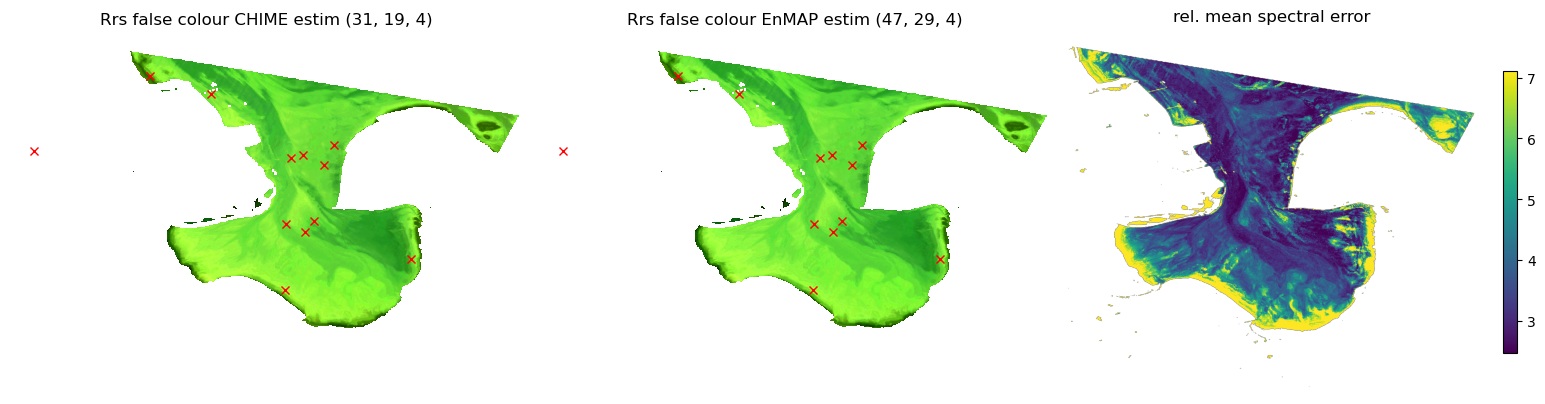

In [24]:
## RGB CHIME
ind665_C, ind665C = find_closest(CHIME_vnir, 665)
ind560_C, ind560C = find_closest(CHIME_vnir, 560)
ind440_C, ind440C = find_closest(CHIME_vnir, 440)

IDnan = np.isnan(Rrs_image[:,:,0])

def rgb_setup(Rrs_estim, IDnan, ind665C, ind560C, ind440C):
    # False-colour RGB for overlay
    rgb_bands = [ind665C, ind560C, ind440C]   # B04, B03, B02 → R, G, B
    rgb = Rrs_estim[..., rgb_bands]
    for i in range(rgb.shape[2]):
        rgb[IDnan, i] = np.nan
    rgb = (rgb - np.nanpercentile(rgb, 2)) / (np.nanpercentile(rgb, 98) - np.nanpercentile(rgb, 2))
    rgb = np.clip(rgb, 0, 1)
    return rgb

## random choice spectrum from water: EnMAP, CHIME
waterID = np.where(np.logical_not(IDnan))
selectID = np.random.choice(np.arange(0, len(waterID[0]),1), size=12, replace=False)
waterY = waterID[0][selectID]
waterX = waterID[1][selectID]

## Plot images

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
offset_X = 600
rgb_CHIME = rgb_setup(CHIME_estim, IDnan, ind665C, ind560C, ind440C)
axes[0].imshow(rgb_CHIME[:, offset_X:,:], origin='upper')
axes[0].plot(waterX-offset_X, waterY, 'rx')
# axes.text(waterY, waterX, [str(i) for i in range(12)], color='red')

BandStr = str(ind665C) + ', ' + str(ind560C) + ', ' + str(ind440C)
axes[0].set_title('Rrs false colour CHIME estim ('+BandStr +')')
axes[0].axis('off')


rgb_EnMAP = rgb_setup(EnMAP_estim, IDnan, ind665, ind560, ind440)
axes[1].imshow(rgb_EnMAP[:, offset_X:,:], origin='upper')
axes[1].plot(waterX-offset_X, waterY, 'rx')
# axes.text(waterY, waterX, [str(i) for i in range(12)], color='red')

BandStr = str(ind665) + ', ' + str(ind560) + ', ' + str(ind440)
axes[1].set_title('Rrs false colour EnMAP estim ('+BandStr +')')
axes[1].axis('off')


## Error EnMAP to CHIME
# only possible with EnMAP to EnMAP!
specMax = np.max(Rrs_image, axis=-1)
errorSpec = np.sum(np.abs(Rrs_image - EnMAP_estim), axis=-1)/specMax
vmin, vmax = np.nanpercentile(errorSpec, [2, 90])
im = axes[2].imshow(errorSpec[:, offset_X:], origin='upper', vmin=vmin, vmax=vmax)
axes[2].set_title('rel. mean spectral error')
axes[2].axis('off')
fig.colorbar(im, ax=axes[2], shrink=0.6)
plt.tight_layout()
plt.show()


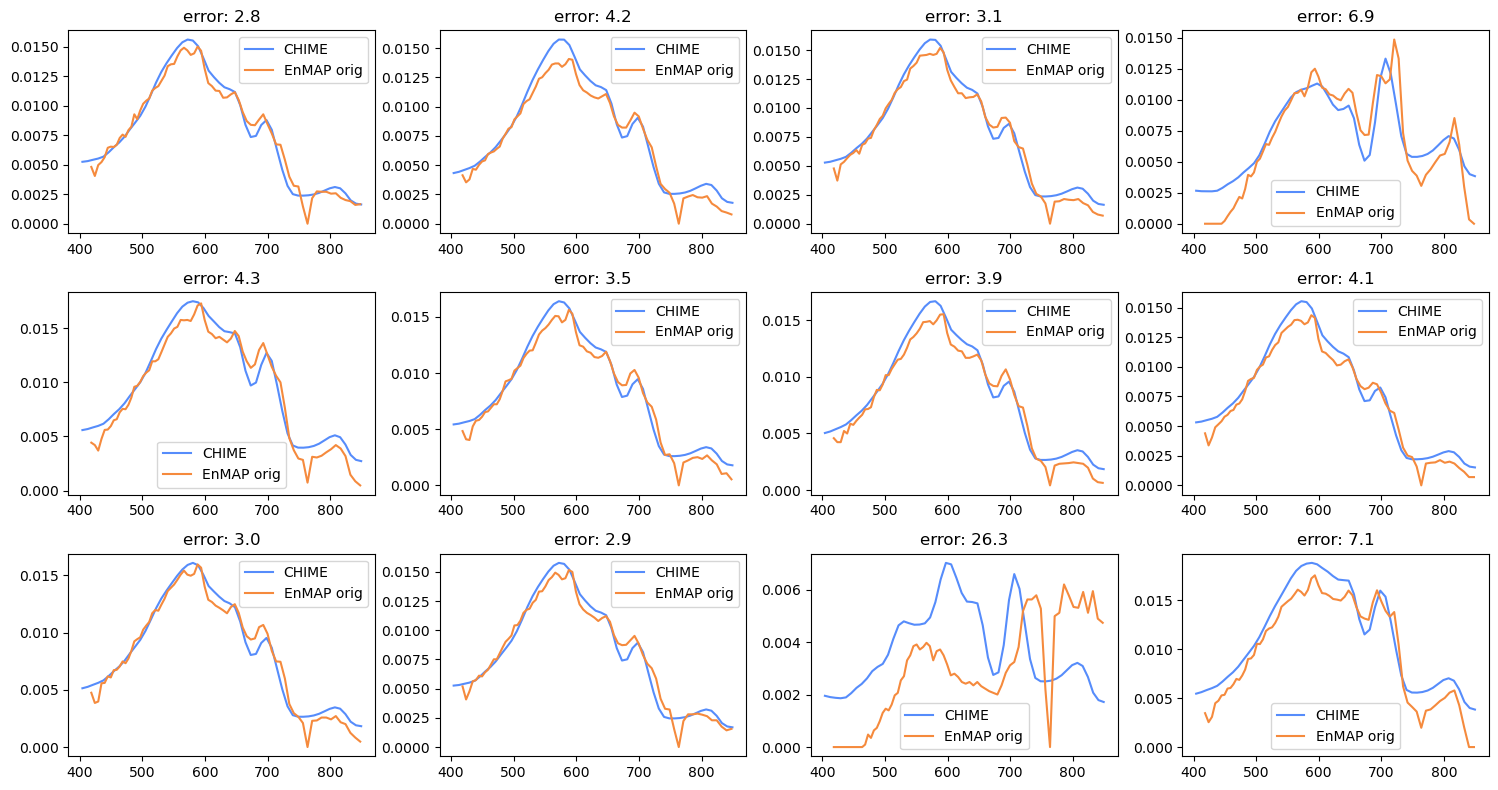

In [26]:
Nx, Ny = (4, 3)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(15, 8))
ix, iy = (0,0)
for wx, wy in zip(waterX, waterY):
    ax[iy, ix].plot(CHIME_vnir, CHIME_estim[wy, wx, :], '-', label='CHIME')
    ax[iy, ix].plot(wavelengths, Rrs_image[wy, wx, :], '-', label='EnMAP orig')
    # ax[iy, ix].plot(wavelengths, EnMAP_estim[wx, wy, :], '-', label='EnMAP sim')
    ax[iy, ix].legend()
    ax[iy, ix].set_title('error: '+ str(np.round(errorSpec[wy, wx], 1)))
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

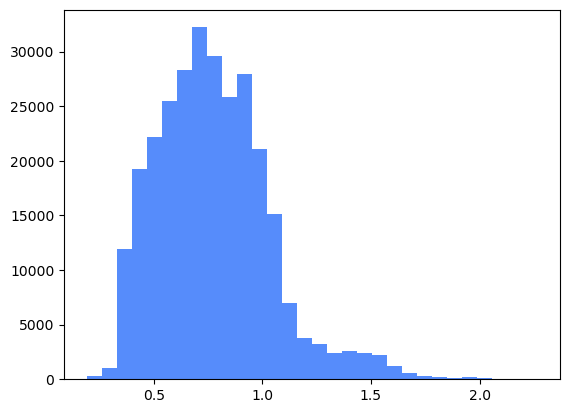

In [129]:
# specMax = np.max(Rrs_image, axis=-1)
# errorSpec2 = np.sum((Rrs_image - EnMAP_estim), axis=-1)/specMax
# bins = np.arange(-50, 20, 1)
plt.hist(np.log10(errorSpec.flatten()), 30)
plt.show()

## Step 6 - Interpolate C_x and all varied parameters

In [27]:
## Interpolation all varied concentrations ##
k            = 4
n_components = 6

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    sp_results['x_hat'],
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0


C_varied_flat  = bp['x_hat']
# sigma_flat  = bp['sigma']
# A_diag_flat = bp['A_diag']

n_fit   = C_varied_flat.shape[-1]
C_varied  = C_varied_flat.reshape(n_rows, n_cols, n_fit)
# sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
# A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {C_varied.shape}')

Back-interpolation: 9.61 s
x_hat shape: (930, 1648, 7)


## Step 7 - CHIME Noise
1. Convert Rrs into Radiance
2. Simplistic transfer to TOA -> ? This needs an estimate for upwelling transmittance ?!
3. SNR

### Reflectance to Radiance

In [28]:
## sun irradiance convolved to CHIME bands!
from netCDF4 import Dataset
# fname = "Y:\EnMAP\solar_irradiance\hybrid_reference_spectrum_p025nm_resolution_c2022-11-30_with_unc.nc" # spectral resolution 0.025nm
fname = "Y:\EnMAP\solar_irradiance\hybrid_reference_spectrum_c2022-11-30_with_unc.nc" # spectral resolution 0.001nm
F0 = Dataset(fname, 'r')

wavelength = F0.variables['Vacuum Wavelength'][:]
SSI = F0.variables['SSI'][:]
ID = np.logical_and(wavelength>380, wavelength<900)
wavelength = wavelength[ID]
SSI = SSI[ID]

In [29]:
def convolve_CHIME_weights(wavelength, CHIME_vnir):
    def ISRF(wl, wl0):
        FWHM = 10.7
        sigma = FWHM/(2*np.sqrt(2*np.log(2)))
        return 1./np.sqrt(2*np.pi*sigma)*np.exp(-1./2.*((wl-wl0)/sigma)**2)

    weights_Arr = np.zeros((len(wavelength), len(CHIME_vnir)))
    for i, wl0 in enumerate(CHIME_vnir):
        weights = ISRF(wavelength, wl0)
        weightsnorm = weights / np.sum(weights)
        weights_Arr[:,i] = weightsnorm

    return weights_Arr

In [30]:
## F0 Unit: W/m2/nm
weights_Arr = convolve_CHIME_weights(wavelength, CHIME_vnir)
F0_CHIME = np.zeros(len(CHIME_vnir))
for i in range(len(CHIME_vnir)):
    F0_CHIME[i] = np.sum(SSI * weights_Arr[:,i])
# F0_CHIME

In [31]:
# reflectance[i] = radiance * math.pi / (E0 * np.cos(np.radians(theta_s)))
## Geometry of EnMAP scene
theta_sun = sun_dict['zenith']
dist = np.asarray(earth_distance(pd.to_datetime(datetime)))
Ed_TOA = F0_CHIME / dist**2 *np.cos(np.deg2rad(theta_sun))

In [32]:
L_surf_CHIME = CHIME_estim / np.pi * Ed_TOA # Chain 1, Unit: W/sr/m2/nm
# L_surf_CHIME = Rrs3D_CHIME / np.pi * Ed_TOA # Chain 2

#### Rayleigh transmittance
single geometry for the scene EnMAP

view_zenith = 7.0

at lat/lon of Tile center point


In [33]:
import json
def json_as_numpy(dct):
	return {key: np.array(value) for key, value in dct.items()}
# constants
AVO = 6.0221367E+23  # Avogadro's number
m_a_zero = 28.9595  # Mean molecular weight of dry air (zero H2O)
g0_45 = 980.616  # Acceleration of gravity (sea level and 458 latitude)
Ns = 2.5469E19  # Molecular density of gas in molecules / cm3 (288.15K, 1013.25mb)

#Ns = Ns * 288.15/243.15 #-30°C in greenland in that summer..

# constants describing the state of the atmosphere and which we don't know; better values may be used if known
CO2 = 3.6E-4  # CO2 concentration at pixel; typical values are 300 to 360 ppm; here: parts per volumn
C_CO2 = 360. / 10000.  # CO2 concentration in part per volume per percent
m_a = 15.0556 * CO2 + m_a_zero  # mean molecular weight of dry air as function of actual CO2

# other constants
PA = 0.9587256  # Rayleigh Phase function, molecular asymetry factor 1
PB = 1. - PA  # Rayleigh Phase function, molecular asymetry factor 2

with open('C:\\Users\Dagmar\PycharmProjects\geoinfopy\sandbox\dagmar\OLCI_smile_correction\\test\\raycorr_auxdata.json', 'r') as fp:
    obj = json.load(fp, object_hook=json_as_numpy)
# json_str = json.dumps(new_aux, cls=JSONNumpyEncoder, indent=2)
# print(json_str)
# obj = json.loads(json_str, object_hook=json_as_numpy)
# rayADF = new_aux
rayADF = obj
ray_coeff_matrix = rayADF['ray_coeff_matrix']

tpoly = rayADF['tau_ray']  # Polynomial coefficients for Rayleigh transmittance

# Rayleigh transmittances and spherical albedo
nbands = CHIME_estim.shape[-1]
tR_thetaS = np.zeros(nbands, dtype=np.float32)  # Rayleigh Transmittance sun - surface
tR_thetaV = np.zeros(nbands, dtype=np.float32)  # Rayleigh Transmittance surface - sensor
sigma = np.zeros(nbands)
alt = 0. # m
press0 = 1032. # hPa
theta_view= 7.0
taur = np.zeros(nbands)

# Calculate the Rayleigh cross section, which depends only on wavelength but not on air pressure
def Rayleigh_crosssection(lam_nm):
    # lam_nm = CHIME_vnir[i]
    lam =  lam_nm / 1000.0  # wavelength in micrometer
    lam2 = lam_nm / 1.E7  # wavelength in cm
    F_N2 = 1.034 + 0.000317 / (lam ** 2)  # King factor of N2
    F_O2 = 1.096 + 0.001385 / (lam ** 2) + 0.0001448 / (lam ** 4)  # King factor of O2
    F_air = (78.084 * F_N2 + 20.946 * F_O2 + 0.934 * 1 + C_CO2 * 1.15) / (
            78.084 + 20.946 + 0.934 + C_CO2)  # depolarization ratio or King Factor, (6+3rho)/(6-7rho)
    n_ratio = 1 + 0.54 * (CO2 - 0.0003)
    #refractive index of dry air with 300ppm CO2:
    n_1_300 = (8060.51 + (2480990. / (132.274 - lam ** (-2))) + (17455.7 / (39.32957 - lam ** (-2)))) / 1.E8
    ## old: nCO2 = n_ratio * (1 + n_1_300)  # reflective index at CO2; THIS WAS AN ERROR!
    nCO2 = n_ratio * n_1_300 + 1  # reflective index at CO2
    return (24 * np.pi**3 * (nCO2**2 - 1)**2) / (lam2**4 * Ns**2 * (nCO2**2 + 2)**2) * F_air

sigma = Rayleigh_crosssection(CHIME_vnir)

# Calculation to get the pressure
z = alt  # altitude at pixel in meters, taken from MERIS tie-point grid
z = max(z, 0)  # clip to sea level
Psurf0 = press0  # pressure at sea level in hPa, taken from MERIS tie-point grid
Psurf = Psurf0 * (1. - 0.0065 * z / 288.15) ** 5.255  # air pressure at the pixel (i.e. at altitude) in hPa, using the international pressure equation
P = Psurf * 1000.  # air pressure at pixel location in dyn / cm2, which is hPa * 1000
# calculation to get the constant of gravity at the pixel altitude, taking the air mass above into account
dphi = np.radians(lat_mean)  # latitude in radians
cos2phi = np.cos(2 * dphi)
g0 = g0_45 * (1 - 0.0026373 * cos2phi + 0.0000059 * cos2phi ** 2)
zs = 0.73737 * z + 5517.56  # effective mass-weighted altitude
g = g0 - (3.085462E-4 + 2.27E-7 * cos2phi) * zs + (7.254E-11 + 1E-13 * cos2phi) * zs**2 - (1.517E-17 + 6E-20 * cos2phi) * zs**3
# calculations to get the Rayleigh optical thickness
factor = (P * AVO) / (m_a * g)
taur = sigma *factor

# Calculate Rayleigh Phase function
ts = np.radians(theta_sun)  # sun zenith angle in radian
cts = np.cos(ts)  # cosine of sun zenith angle
sts = np.sin(ts)  # sinus of sun zenith angle
tv = np.radians(theta_view)  # view zenith angle in radian
ctv = np.cos(tv)  # cosine of view zenith angle
stv = np.sin(tv)  # sinus of view zenith angle
airmass = 1. / cts + 1. / ctv  # air mass

# polynomial coefficients tpoly0, tpoly1 and tpoly2 from MERIS LUT
tRs = ((2. / 3. + cts) + (2. / 3. - cts) * np.exp(-taur / cts)) / (4. / 3. + taur)
# Rayleigh Transmittance sun - surface
tR_thetaS = tpoly[0] + tpoly[1] * tRs + tpoly[2] * tRs ** 2
tRv = ((2. / 3. + ctv) + (2. / 3. - ctv) * np.exp(-taur / ctv)) / (4. / 3. + taur)
# Rayleigh Transmittance surface - sensor
tR_thetaV = tpoly[0] + tpoly[1] * tRv + tpoly[2] * tRv ** 2

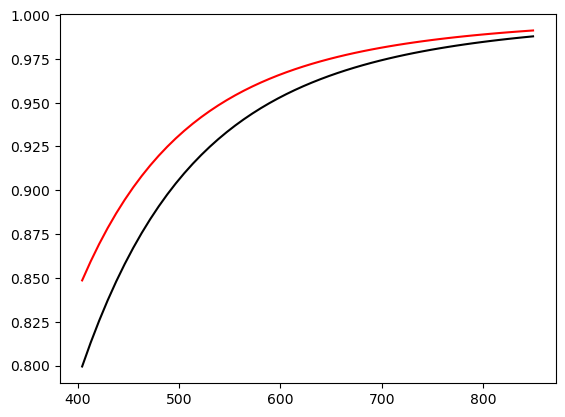

In [34]:
plt.plot(CHIME_vnir, tR_thetaS, 'k-')
plt.plot(CHIME_vnir, tR_thetaV, 'r-')
plt.show()

#### L_TOA estimate, convolve L_ref, SNR value per band and pixel
Lref Unit: W/sr/m2/micron! -> 10^-3 * W/sr/m2/nm

In [35]:
pathSNR = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\CHIME_SNR\\"

# SNR = pd.read_csv(pathSNR + "SNR_g_No_coeff.csv", header=0)
Ref = pd.read_csv(pathSNR + "SSRD_AD11 CHIME radiance levels v4.csv", header=0)
# convolve to CHIME
weights_Arr = convolve_CHIME_weights(Ref.iloc[:,0], CHIME_vnir)
L_ref_CHIME = np.zeros(len(CHIME_vnir))
for i in range(len(CHIME_vnir)):
    L_ref_CHIME[i] = np.sum(Ref.iloc[:,2] * weights_Arr[:,i])

In [36]:
L_TOA_CHIME = np.asarray(10.*L_surf_CHIME * tR_thetaV) # tR_thetaV is an astropy class! W/sr/m2/nm -> 10^3 * W/sr/m2/micron
rLTOA = 1000. * L_TOA_CHIME / L_ref_CHIME
IDbands = np.logical_and(SNR.iloc[:,0]>=np.min(CHIME_vnir), SNR.iloc[:,0]<=np.max(CHIME_vnir))

for j in range(rLTOA.shape[2]):
    rLTOA[IDnan, j] = np.nan

SNR_CHIME =  rLTOA * SNR.g.values[IDbands] * 1./np.sqrt(rLTOA + SNR.N0.values[IDbands])

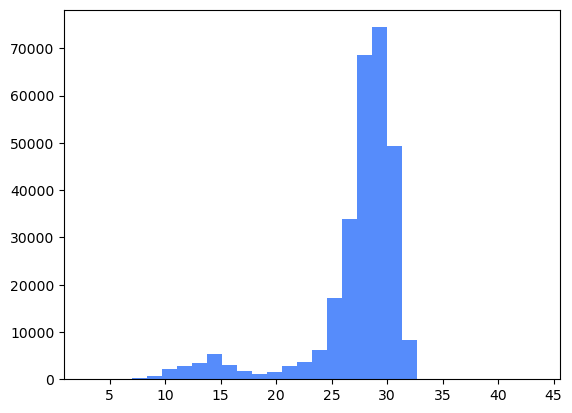

In [80]:
plt.hist(SNR_CHIME[:,:, 0].reshape(SNR_CHIME.shape[0]*SNR_CHIME.shape[1]), 30)
plt.show()

72.72358232986304


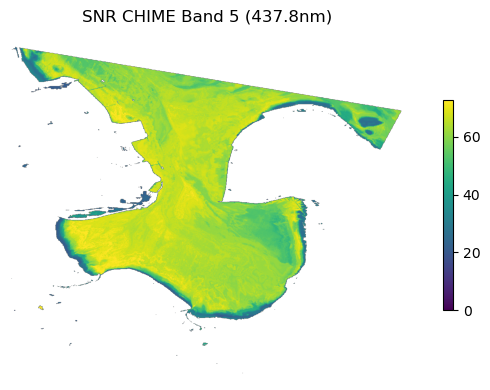

In [37]:
bandN = 4
fig, ax = plt.subplots(figsize=(8,4))
vmax= np.nanpercentile(SNR_CHIME[:,:, bandN], 99)
print(vmax)
im = ax.imshow(SNR_CHIME[:,offset_X:, bandN], vmin=0, vmax=vmax)
fig.colorbar(im, ax=ax, shrink=0.6)
ax.set_title('SNR CHIME Band '+str(bandN+1)+ ' (' + str(CHIME_vnir[bandN]) + 'nm)')
ax.axis('off')
fig.tight_layout()
plt.show()

#### Apply SNR to Rrs spectra

In [38]:
## Noise to remote sensing reflectance at surface
NOISE_Rrs = 10. * CHIME_estim / SNR_CHIME * np.random.normal(size=CHIME_estim.shape)

In [39]:
CHIME_estim_withNoise = CHIME_estim + NOISE_Rrs

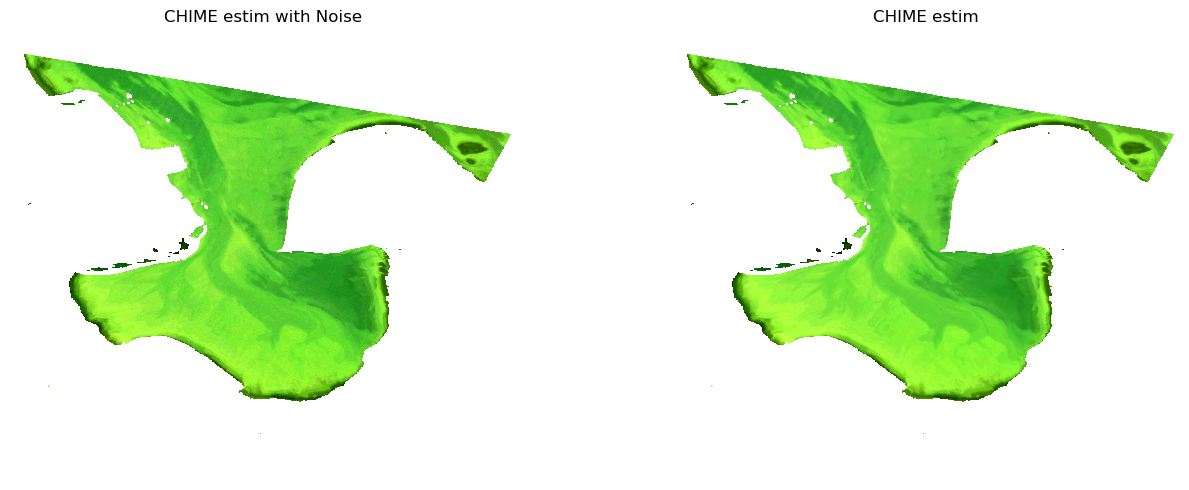

In [94]:
# False-colour RGB for overlay
rgb_bands = [ind665C, ind560C, ind440C]   # B04, B03, B02 → R, G, B
rgb_noise = CHIME_estim_withNoise[..., rgb_bands]
for i in range(rgb_noise.shape[2]):
    rgb_noise[IDnan, i] = np.nan
rgb_noise = (rgb_noise - np.nanpercentile(rgb_noise, 2)) / (np.nanpercentile(rgb_noise, 98) - np.nanpercentile(rgb_noise, 2))
rgb_noise = np.clip(rgb_noise, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb_noise[:,offset_X:,:], origin='upper')
axes[0].axis('off')
axes[0].set_title('CHIME estim with Noise')
axes[1].imshow(rgb_CHIME[:, offset_X:,:], origin='upper')
axes[1].axis('off')
axes[1].set_title('CHIME estim')
fig.tight_layout()
plt.show()

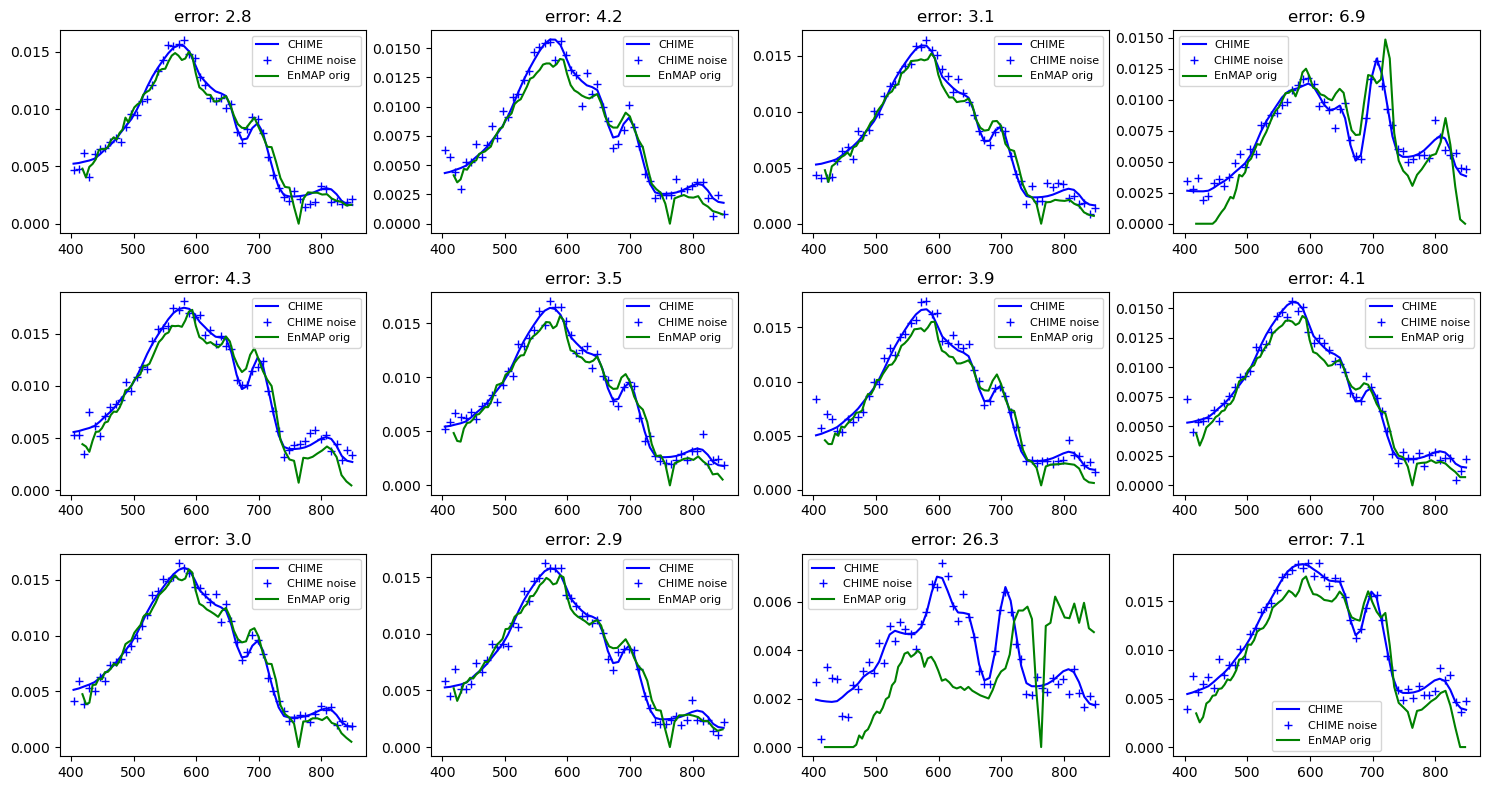

In [40]:
Nx, Ny = (4, 3)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(15, 8))
ix, iy = (0,0)
for wx, wy in zip(waterX, waterY):
    ax[iy, ix].plot(CHIME_vnir, CHIME_estim[wy, wx, :], 'b-', label='CHIME')
    ax[iy, ix].plot(CHIME_vnir, CHIME_estim_withNoise[wy, wx, :], 'b+', label='CHIME noise')
    ax[iy, ix].plot(wavelengths, Rrs_image[wy, wx, :], 'g-', label='EnMAP orig')
    # ax[iy, ix].plot(wavelengths, EnMAP_estim[wx, wy, :], '-', label='EnMAP sim')
    ax[iy, ix].legend(fontsize=8)
    ax[iy, ix].set_title('error: '+ str(np.round(errorSpec[wy, wx], 1)))
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

## **Step 8 - Write CHIME to File**
outputs are:
- simulated CHIME spectra (with noise)
- all varied inversion properties to allow reconstruction of spectrum without noise
- goodness of fit to original EnMAP spectrum

In [41]:
spatial_dim_names

['y', 'x']

In [42]:
spatial_coords

{'y': array([53.69333056, 53.69295104, 53.69257153, 53.69219201, 53.69181249,
        53.69143298, 53.69105346, 53.69067394, 53.69029443, 53.68991491,
        53.6895354 , 53.68915588, 53.68877636, 53.68839685, 53.68801733,
        53.68763782, 53.6872583 , 53.68687878, 53.68649927, 53.68611975,
        53.68574023, 53.68536072, 53.6849812 , 53.68460169, 53.68422217,
        53.68384265, 53.68346314, 53.68308362, 53.68270411, 53.68232459,
        53.68194507, 53.68156556, 53.68118604, 53.68080652, 53.68042701,
        53.68004749, 53.67966798, 53.67928846, 53.67890894, 53.67852943,
        53.67814991, 53.6777704 , 53.67739088, 53.67701136, 53.67663185,
        53.67625233, 53.67587281, 53.6754933 , 53.67511378, 53.67473427,
        53.67435475, 53.67397523, 53.67359572, 53.6732162 , 53.67283668,
        53.67245717, 53.67207765, 53.67169814, 53.67131862, 53.6709391 ,
        53.67055959, 53.67018007, 53.66980056, 53.66942104, 53.66904152,
        53.66866201, 53.66828249, 53.66790297,

In [43]:
ds = xr.Dataset({
    'bands': xr.DataArray(
        CHIME_estim_withNoise, dims=('y', 'x', 'wl'),
        coords={**spatial_coords, 'wl': CHIME_vnir},
    ),

    # 'chi2':            xr.DataArray(chi2,     dims=('y', 'x'), coords=spatial_coords),
    # 'chi2_calibrated': xr.DataArray(chi2_cal, dims=('y', 'x'), coords=spatial_coords),
    # 'chi2_spectral':   xr.DataArray(chi2_sp,  dims=('y', 'x'), coords=spatial_coords),
})

for i, v in enumerate(sp_results['fit_names']):
    temp = xr.DataArray(C_varied[:,:,i], dims=('y', 'x'), coords=spatial_coords)
    ds[v] = temp

outpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\EnMAP2CHIME_sim\\"
ds.to_netcdf(outpath + 'CHIME_' +zarrFname.split('____')[1].split('.zarr')[0]+ '.nc')
